<a href="https://colab.research.google.com/github/nhannguyen31251025060-cyber/Code_AI/blob/main/AI_cu%E1%BB%91i_k%C3%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install gradio opencv-python-headless

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
import re
import cv2
import json
import glob
import time
import shutil
import random
import unicodedata
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import gradio as gr

from PIL import Image, ImageDraw, ImageFont
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "/content/drive/MyDrive/food_dataset"
PROJECT_DIR = "/content/drive/MyDrive/food_ai_project"

MODEL_PATH = os.path.join(PROJECT_DIR, "food_model_fixed_v1.keras")
LABEL_PATH = os.path.join(PROJECT_DIR, "labels_fixed_v1.json")
MENU_PATH = os.path.join(PROJECT_DIR, "menu_fixed_v1.json")
CROP_SAVE_DIR = os.path.join(PROJECT_DIR, "cropped_dishes_fixed")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(CROP_SAVE_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_HEAD = 10
EPOCHS_FINE = 10

FORCE_RETRAIN = True

USE_LOCAL_COPY = True
REFRESH_LOCAL_COPY = True

LOCAL_DATA_DIR = "/content/food_dataset_fast"
TRAIN_DATA_DIR = LOCAL_DATA_DIR if USE_LOCAL_COPY else DATA_DIR

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
from tensorflow.keras import mixed_precision

try:
    mixed_precision.set_global_policy("mixed_float16")
    print("Đã bật mixed precision để train nhanh hơn.")
except Exception as e:
    print("Không bật được mixed precision:", e)

try:
    tf.config.optimizer.set_jit(True)
    print("Đã bật XLA acceleration.")
except Exception as e:
    print("Không bật được XLA:", e)

if USE_LOCAL_COPY:
    if REFRESH_LOCAL_COPY and os.path.exists(LOCAL_DATA_DIR):
        print("Đang xóa dataset local cũ để copy lại bản mới từ Drive...")
        shutil.rmtree(LOCAL_DATA_DIR)

    if not os.path.exists(LOCAL_DATA_DIR):
        print("Đang copy dataset từ Drive sang /content để train nhanh hơn...")
        shutil.copytree(DATA_DIR, LOCAL_DATA_DIR)
        print("Copy xong:", LOCAL_DATA_DIR)
    else:
        print("Dataset local đã tồn tại:", LOCAL_DATA_DIR)

print("Folder train đang dùng:", TRAIN_DATA_DIR)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("DATA_DIR:", DATA_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("MODEL_PATH:", MODEL_PATH)

Mounted at /content/drive
Đã bật mixed precision để train nhanh hơn.
Đã bật XLA acceleration.
Đang copy dataset từ Drive sang /content để train nhanh hơn...
Copy xong: /content/food_dataset_fast
Folder train đang dùng: /content/food_dataset_fast
TensorFlow: 2.20.0
GPU: []
DATA_DIR: /content/drive/MyDrive/food_dataset
PROJECT_DIR: /content/drive/MyDrive/food_ai_project
MODEL_PATH: /content/drive/MyDrive/food_ai_project/food_model_fixed_v1.keras


,class_folder,normalized_name,num_images
0,ca,ca,302
1,canh chua,canh chua,232
2,canh chua co ca,canh chua co ca,71
3,com,com,144
4,dau hu,dau hu,300
5,rau,rau,303
6,suon,suon,2001
7,thit kho,thit kho,300
8,thit kho trung,thit kho trung,292
9,trung,trung,300


CẢNH BÁO: Đề yêu cầu lớn hơn 10 món. Hiện tại số class là: 10


,class_folder,Tên món hiển thị,Giá,Ghi chú
0,ca,Cá hú kho,30000,
1,canh chua,Canh chua không cá,10000,
2,canh chua co ca,Canh chua có cá,25000,
3,com,Cơm trắng,10000,
4,dau hu,Đậu hũ sốt cà,25000,
5,rau,Rau xào,10000,
6,suon,Sườn nướng,30000,
7,thit kho,Thịt kho,25000,
8,thit kho trung,Thịt kho trứng,30000,
9,trung,Trứng chiên,25000,


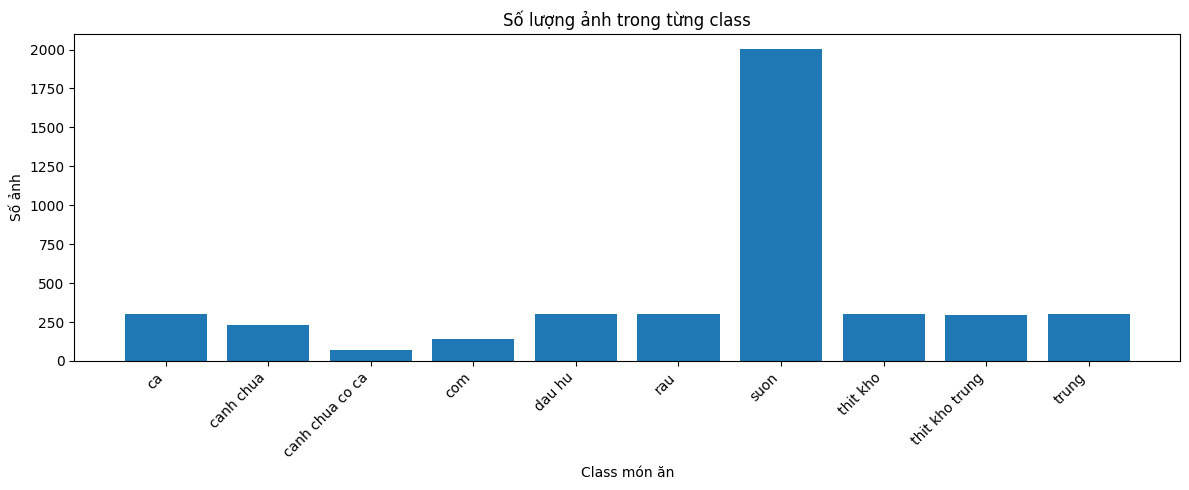

In [3]:
 def normalize_text(text):
    text = str(text).strip().lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    text = text.replace("_", " ").replace("-", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def count_images(folder):
    total = 0
    for ext in IMG_EXTENSIONS:
        total += len(glob.glob(os.path.join(folder, f"*{ext}")))
        total += len(glob.glob(os.path.join(folder, f"*{ext.upper()}")))
    return total

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError("Không tìm thấy folder food_dataset trong MyDrive.")

class_names = sorted([
    name for name in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, name)) and not name.startswith(".")
])

if len(class_names) == 0:
    raise ValueError("food_dataset chưa có folder món ăn nào.")

dataset_info = []

for cls in class_names:
    folder = os.path.join(DATA_DIR, cls)
    dataset_info.append({
        "class_folder": cls,
        "normalized_name": normalize_text(cls),
        "num_images": count_images(folder)
    })

dataset_df = pd.DataFrame(dataset_info)
display(dataset_df)

if len(class_names) <= 10:
    print("CẢNH BÁO: Đề yêu cầu lớn hơn 10 món. Hiện tại số class là:", len(class_names))
else:
    print("OK. Số class:", len(class_names))

empty_classes = dataset_df[dataset_df["num_images"] == 0]["class_folder"].tolist()
if empty_classes:
    print("Các folder chưa có ảnh:", empty_classes)

low_classes = dataset_df[dataset_df["num_images"] < 50]["class_folder"].tolist()
if low_classes:
    print("Các folder hơi ít ảnh, nên bổ sung thêm:", low_classes)

DEFAULT_MENU_BY_NORM = {
    "com": {"display_name": "Cơm trắng", "price": 10000, "note": ""},
    "ca": {"display_name": "Cá hú kho", "price": 30000, "note": ""},
    "canh chua": {"display_name": "Canh chua không cá", "price": 10000, "note": ""},
    "canh chua co ca": {"display_name": "Canh chua có cá", "price": 25000, "note": ""},
    "canh rau": {"display_name": "Canh rau", "price": 7000, "note": ""},
    "dau hu": {"display_name": "Đậu hũ sốt cà", "price": 25000, "note": ""},
    "rau": {"display_name": "Rau xào", "price": 10000, "note": ""},
    "suon": {"display_name": "Sườn nướng", "price": 30000, "note": ""},
    "thit kho": {"display_name": "Thịt kho", "price": 25000, "note": ""},
    "thit kho trung": {"display_name": "Thịt kho trứng", "price": 30000, "note": ""},
    "trung": {"display_name": "Trứng chiên", "price": 25000, "note": ""}
}

def guess_display_and_price(class_name):
    norm = normalize_text(class_name)

    if norm in DEFAULT_MENU_BY_NORM:
        return DEFAULT_MENU_BY_NORM[norm]

    return {
        "display_name": class_name,
        "price": 15000,
        "note": "Giá mặc định, có thể sửa trong menu_fixed_v1.json"
    }

MENU_INFO = {}

for cls in class_names:
    MENU_INFO[cls] = guess_display_and_price(cls)

with open(MENU_PATH, "w", encoding="utf-8") as f:
    json.dump(MENU_INFO, f, ensure_ascii=False, indent=4)

with open(LABEL_PATH, "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=4)

menu_df = pd.DataFrame([
    {
        "class_folder": cls,
        "Tên món hiển thị": MENU_INFO[cls]["display_name"],
        "Giá": MENU_INFO[cls]["price"],
        "Ghi chú": MENU_INFO[cls].get("note", "")
    }
    for cls in class_names
])

display(menu_df)

plt.figure(figsize=(12, 5))
plt.bar(dataset_df["class_folder"], dataset_df["num_images"])
plt.xticks(rotation=45, ha="right")
plt.title("Số lượng ảnh trong từng class")
plt.xlabel("Class món ăn")
plt.ylabel("Số ảnh")
plt.tight_layout()
plt.show()

Found 4245 files belonging to 10 classes.
Using 3396 files for training.
Found 4245 files belonging to 10 classes.
Using 849 files for validation.
Class names:
0 ca
1 canh chua
2 canh chua co ca
3 com
4 dau hu
5 rau
6 suon
7 thit kho
8 thit kho trung
9 trung
Số ảnh từng class:
{'ca': 302, 'canh chua': 232, 'canh chua co ca': 71, 'com': 144, 'dau hu': 300, 'rau': 303, 'suon': 2001, 'thit kho': 300, 'thit kho trung': 292, 'trung': 300}
Class weight:
{0: 1.4056291390728477, 1: 1.8297413793103448, 2: 5.97887323943662, 3: 2.9479166666666665, 4: 1.415, 5: 1.400990099009901, 6: 0.212143928035982, 7: 1.415, 8: 1.4537671232876712, 9: 1.415}


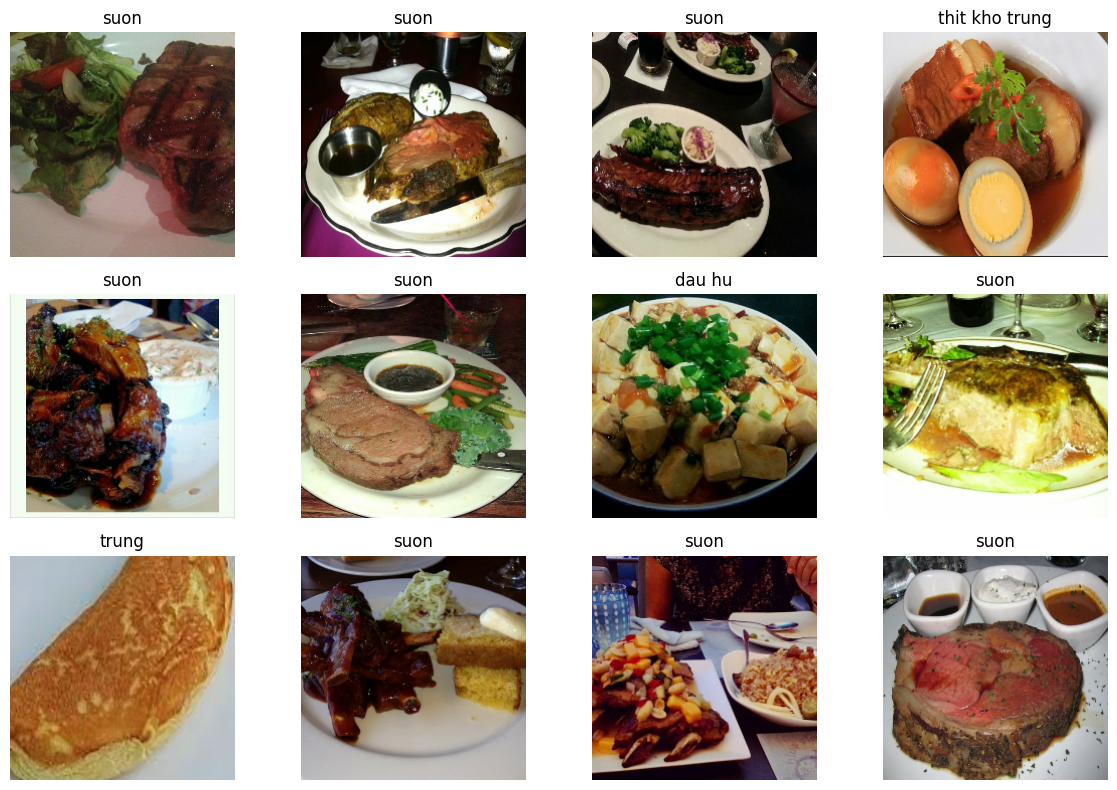

In [4]:
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)

with open(LABEL_PATH, "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=4)

print("Class names:")
for i, name in enumerate(class_names):
    print(i, name)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = raw_train_ds.cache("/content/train_cache").shuffle(2000).prefetch(AUTOTUNE)
val_ds = raw_val_ds.cache("/content/val_cache").prefetch(AUTOTUNE)

counts = {}

for cls in class_names:
    counts[cls] = count_images(os.path.join(TRAIN_DATA_DIR, cls))

total_images = sum(counts.values())

class_weight = {}

for i, cls in enumerate(class_names):
    if counts[cls] > 0:
        class_weight[i] = total_images / (num_classes * counts[cls])
    else:
        class_weight[i] = 1.0

print("Số ảnh từng class:")
print(counts)

print("Class weight:")
print(class_weight)

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def build_food_model(num_classes):
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.06),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.15),
        layers.RandomTranslation(0.04, 0.04)
    ], name="data_augmentation")

    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0)(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model, base_model

if os.path.exists(MODEL_PATH) and not FORCE_RETRAIN:
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Đã load model có sẵn:", MODEL_PATH)
else:
    model, base_model = build_food_model(num_classes)

    callbacks = [
        EarlyStopping(
            monitor="val_accuracy",
            patience=7,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7
        ),
        ModelCheckpoint(
            MODEL_PATH,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        )
    ]

    print("Train lần 1: train phần classifier...")
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        class_weight=class_weight,
        callbacks=callbacks
    )

    print("Fine-tune: mở một phần MobileNetV2...")
    base_model.trainable = True

    for layer in base_model.layers[:-45]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINE,
        class_weight=class_weight,
        callbacks=callbacks
    )

    model.save(MODEL_PATH)

    print("Đã lưu model mới tại:", MODEL_PATH)

print("Số output của model:", model.output_shape[-1])
print("Số labels:", len(class_names))

if model.output_shape[-1] != len(class_names):
    raise ValueError("Model và labels bị lệch. Cần train lại từ đầu.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train lần 1: train phần classifier...
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3723 - loss: 1.9414
Epoch 1: val_accuracy improved from None to 0.91637, saving model to /content/drive/MyDrive/food_ai_project/food_model_fixed_v1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/food_ai_project/food_model_fixed_v1.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1064s 10s/step - accuracy: 0.5551 - loss: 1.2688 - val_accuracy: 0.9164 - val_loss: 0.3376 - learning_rate: 5.0000e-04
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7757 - loss: 0.5050
Epoch 2: val_accuracy improved from 0.91637 to 0.93168, saving model to /content/drive/MyDrive/food_ai_project/food_model_fixed_v1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/food_ai_project/food_model_fixed_v1.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1027s 10s/step - accuracy: 0.8021 - loss: 0.5179 - val_accuracy: 0.9317 - val_loss: 0.2387 - le

In [2]:
val_loss, val_acc = model.evaluate(val_ds)
print("Validation accuracy:", round(val_acc * 100, 2), "%")

y_true = []
y_pred = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_pred.extend(preds.tolist())
    y_true.extend(labels.numpy().astype(int).tolist())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

In [3]:
model.save('keras_model.h5')

NameError: name 'model' is not defined